# Xây dựng Thuật toán Naive Bayes(from scratch) để Phân loại Email Rác


## 1. Cơ sở lý thuyết của Multinomial Naive Bayes cho phân loại văn bản

Naive Bayes dựa trên Định lý Bayes với giả định ngây thơ rằng tất cả các từ trong văn bản độc lập với nhau khi biết trước nhãn của văn bản.

### Định lý Bayes cho phân loại lớp $C_k$:
$$P(C_k \mid d) = \frac{P(C_k) P(d \mid C_k)}{P(d)}$$
Trong đó, $d$ là một tài liệu (email) biểu diễn dưới dạng véc-tơ tần suất từ $d = (w_1, w_2, ..., w_n)$. Vì mẫu số $P(d)$ là hằng số đối với mọi lớp, ta chỉ cần tối đa hóa tử số:
$$C^* = \arg\max_{C_k} P(C_k) P(w_1, w_2, ..., w_n \mid C_k)$$

Áp dụng giả định độc lập ngây thơ:
$$P(w_1, w_2, ..., w_n \mid C_k) = \prod_{i=1}^{n} P(w_i \mid C_k)$$

### Tránh tràn số dưới (Underflow) bằng phép lấy Logarithm:
Nhân nhiều xác suất nhỏ ($< 1$) sẽ dẫn đến tràn số dưới trong máy tính. Do đó, chúng ta chuyển sang phép cộng trong miền log:
$$\log P(C_k \mid d) \propto \log P(C_k) + \sum_{i=1}^{n} w_i \log P(w_i \mid C_k)$$
Trong đó, $w_i$ là số lần xuất hiện của từ thứ $i$ trong tài liệu $d$.

### Mịn hóa Laplace (Laplace Smoothing):
Nếu một từ xuất hiện trong tập kiểm thử nhưng không có trong tập huấn luyện của lớp $C_k$, xác suất $P(w_i \mid C_k)$ sẽ bằng $0$, làm cho toàn bộ tích/tổng bằng $-\infty$. Để xử lý việc này, ta thêm tham số mịn hóa $\alpha$ (thường $\alpha = 1$):
$$P(w_i \mid C_k) = \frac{N_{C_k, w_i} + \alpha}{N_{C_k} + \alpha \cdot |V|}$$
Trong đó:
- $N_{C_k, w_i}$: Tổng số lần từ $w_i$ xuất hiện trong các tài liệu thuộc lớp $C_k$.
- $N_{C_k}$: Tổng số lượng tất cả các từ xuất hiện trong lớp $C_k$.
- $|V|$: Kích thước từ điển (tổng số từ duy nhất trên toàn bộ dữ liệu huấn luyện).

## 2. Khai báo thư viện cơ bản

Chúng ta chỉ sử dụng các thư viện cơ bản để xử lý dữ liệu và vẽ đồ thị (`numpy`, `pandas`, `matplotlib`, `seaborn`).

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

## 3. Tự cài đặt bộ trích xuất đặc trưng Bag-of-Words (`TextVectorizer`)

Bộ trích xuất này sẽ quét qua toàn bộ tài liệu huấn luyện để xây dựng từ điển gồm $K$ từ xuất hiện nhiều nhất, sau đó biểu diễn mỗi email dưới dạng một véc-tơ tần suất từ có độ dài $K$.

In [34]:
class TextVectorizerFromScratch:
    """
    Bộ trích xuất đặc trưng đếm tần suất từ (Bag of Words) tự cài đặt.
    """
    def __init__(self, max_features=None):
        self.max_features = max_features
        self.vocabulary_ = {}
        
    def fit(self, texts):
        # Đếm tần suất xuất hiện của mọi từ trên toàn bộ văn bản huấn luyện
        word_counts = {}
        for text in texts:
            words = str(text).split() # Các từ đã được tiền xử lý phân tách bằng dấu cách
            for word in words:
                word_counts[word] = word_counts.get(word, 0) + 1
                
        # Sắp xếp các từ theo tần suất giảm dần
        sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
        if self.max_features is not None:
            sorted_words = sorted_words[:self.max_features]
            
        # Tạo từ điển mapping từ -> index cột
        self.vocabulary_ = {word: i for i, (word, _) in enumerate(sorted_words)}
        return self
        
    def transform(self, texts):
        n_samples = len(texts)
        n_features = len(self.vocabulary_)
        X = np.zeros((n_samples, n_features))
        
        for i, text in enumerate(texts):
            words = str(text).split()
            for word in words:
                if word in self.vocabulary_:
                    X[i, self.vocabulary_[word]] += 1
        return X
        
    def fit_transform(self, texts):
        return self.fit(texts).transform(texts)

## 4. Tự cài đặt thuật toán Multinomial Naive Bayes

Lớp `NaiveBayesClassifierFromScratch` sẽ tự thực hiện tính toán xác suất hậu nghiệm lớn nhất dựa trên các logarit xác suất và áp dụng mịn hóa Laplace.

In [35]:
class NaiveBayesClassifierFromScratch:
    def __init__(self, alpha=1.0):
        self.alpha = alpha  # Tham số mịn hóa Laplace
        self.classes = None
        self.class_priors = {}
        self.word_likelihoods = {}
        self.vocab_size = 0
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        self.vocab_size = n_features
        
        for c in self.classes:
            # Lọc các dòng dữ liệu thuộc lớp c
            X_c = X[y == c]
            
            # 1. Tính xác suất tiên nghiệm của lớp P(C) = N_c / N
            self.class_priors[c] = X_c.shape[0] / n_samples
            
            # 2. Tính tổng số từ xuất hiện trong lớp c
            total_words_c = np.sum(X_c)
            
            # 3. Tính số lần xuất hiện của từng từ (từng cột đặc trưng) trong lớp c
            word_counts_c = np.sum(X_c, axis=0)
            
            # 4. Tính P(w_i | C) kết hợp mịn hóa Laplace
            # P(w_i | C) = (count(w_i, C) + alpha) / (total_words_C + alpha * vocab_size)
            self.word_likelihoods[c] = (word_counts_c + self.alpha) / (total_words_c + self.alpha * self.vocab_size)
            
        return self
        
    def predict(self, X):
        n_samples = X.shape[0]
        predictions = []
        
        for i in range(n_samples):
            x = X[i]
            posteriors = {}
            
            for c in self.classes:
                # log P(C)
                log_prior = np.log(self.class_priors[c])
                
                # sum_i (x_i * log P(w_i | C))
                log_likelihood = np.sum(x * np.log(self.word_likelihoods[c]))
                
                # log P(C | d)
                posteriors[c] = log_prior + log_likelihood
                
            # Chọn lớp có điểm số xác suất hậu nghiệm log lớn nhất
            predictions.append(max(posteriors, key=posteriors.get))
            
        return np.array(predictions)

## 5. Tự cài đặt các Hàm Tính Toán Độ đo

Các hàm tính Accuracy, Precision, Recall và F1-score để đánh giá chính xác chất lượng dự báo của mô hình.

In [36]:
def compute_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def compute_precision(y_true, y_pred, pos_label='spam'):
    tp = np.sum((y_true == pos_label) & (y_pred == pos_label))
    fp = np.sum((y_true != pos_label) & (y_pred == pos_label))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def compute_recall(y_true, y_pred, pos_label='spam'):
    tp = np.sum((y_true == pos_label) & (y_pred == pos_label))
    fn = np.sum((y_true == pos_label) & (y_pred != pos_label))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def compute_f1_score(y_true, y_pred, pos_label='spam'):
    p = compute_precision(y_true, y_pred, pos_label)
    r = compute_recall(y_true, y_pred, pos_label)
    return 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0

def train_test_split(X, y, test_size=0.2, shuffle=True, seed=None):
    """Tự cài đặt phân chia tập dữ liệu train và test"""
    if shuffle:
        if seed is not None:
            np.random.seed(seed)
        idx = np.arange(X.shape[0])
        np.random.shuffle(idx)
        X = X[idx]
        y = y[idx]
    split_i = len(y) - int(len(y) * test_size)
    return X[:split_i], X[split_i:], y[:split_i], y[split_i:]

## 6. Đọc Dữ liệu Enron đã Tiền xử lý và Tiến hành Huấn luyện

Load dữ liệu từ file `implementation/data/preprocessed/enron_spam_data_preprocessed_vqd.csv`. Dữ liệu này đã được loại bỏ stop words, lemmatize, xóa thẻ HTML và được ghi xuống file CSV.

In [37]:
# 1. Đọc tệp tin dữ liệu đã tiền xử lý
df = pd.read_csv('/Users/vqd2k6/Desktop/Học máy - UTH/Pra_1/UTH-MACHINE-LEARNING-ASSIGNMENTS-GR02/practice_1/implementation/data/preprocessed/enron_spam_data_preprocessed_vqd.csv')

# Điền giá trị trống bằng chuỗi rỗng
df['Subject'] = df['Subject'].fillna('')
df['Message'] = df['Message'].fillna('')

# Kết hợp cả tiêu đề và nội dung email thành một chuỗi duy nhất
df['Text'] = df['Subject'] + ' ' + df['Message']

print(f"Tổng số mẫu dữ liệu: {len(df)}")
print(df['Label'].value_counts())

# 2. Phân chia tập dữ liệu huấn luyện và kiểm thử (80% Train, 20% Test)
texts = df['Text'].values
labels = df['Label'].values

X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, shuffle=True, seed=42)

print(f"Tập Train: {len(X_train)} mẫu, Tập Test: {len(X_test)} mẫu")

# 3. Trích xuất đặc trưng Bag-of-Words (sử dụng 5000 đặc trưng từ điển nhiều nhất)
vectorizer = TextVectorizerFromScratch(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Kích thước ma trận đặc trưng Train: {X_train_vec.shape}")

Tổng số mẫu dữ liệu: 30489
Label
ham     15910
spam    14579
Name: count, dtype: int64
Tập Train: 24392 mẫu, Tập Test: 6097 mẫu
Kích thước ma trận đặc trưng Train: (24392, 5000)


## 7. Huấn luyện Mô hình Naive Bayes và Dự đoán

In [38]:
# Khởi tạo bộ phân loại
clf = NaiveBayesClassifierFromScratch(alpha=1.0)

# Huấn luyện mô hình
clf.fit(X_train_vec, y_train)

# Dự đoán nhãn cho tập Test
y_pred = clf.predict(X_test_vec)

## 8. Đánh giá Hiệu năng và Vẽ Ma trận nhầm lẫn (Confusion Matrix)

Hãy xem các chỉ số đánh giá mà thuật toán tự viết đạt được trên tập kiểm thử.

=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH NAIVE BAYES TỰ VIẾT ===
Độ chính xác (Accuracy):   97.2938%
Độ chính xác dự báo (Precision): 97.1631%
Độ nhạy/Độ thu hồi (Recall):     97.2617%
Điểm F1-Score:             97.2124%


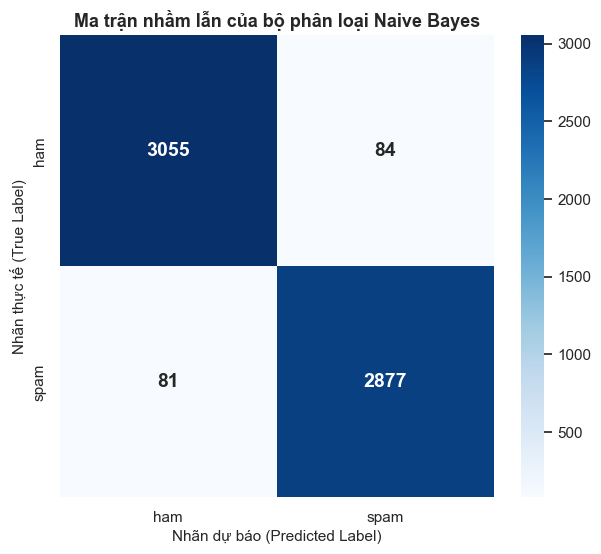

In [39]:
# Tính toán các độ đo
accuracy = compute_accuracy(y_test, y_pred)
precision = compute_precision(y_test, y_pred, pos_label='spam')
recall = compute_recall(y_test, y_pred, pos_label='spam')
f1 = compute_f1_score(y_test, y_pred, pos_label='spam')

print("=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH NAIVE BAYES TỰ VIẾT ===")
print(f"Độ chính xác (Accuracy):   {accuracy:.4%}")
print(f"Độ chính xác dự báo (Precision): {precision:.4%}")
print(f"Độ nhạy/Độ thu hồi (Recall):     {recall:.4%}")
print(f"Điểm F1-Score:             {f1:.4%}")

# 2. Xây dựng ma trận nhầm lẫn từ đầu
classes = ['ham', 'spam']
cm = np.zeros((2, 2), dtype=int)
for i, true_label in enumerate(classes):
    for j, pred_label in enumerate(classes):
        cm[i, j] = np.sum((y_test == true_label) & (y_pred == pred_label))

# 3. Vẽ đồ thị nhiệt Confusion Matrix
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=classes, 
    yticklabels=classes,
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title("Ma trận nhầm lẫn của bộ phân loại Naive Bayes", fontsize=13, fontweight="bold")
plt.ylabel("Nhãn thực tế (True Label)", fontsize=11)
plt.xlabel("Nhãn dự báo (Predicted Label)", fontsize=11)
plt.show()

## 9. So sánh Độ chính xác & Hiệu năng thời gian với Thư viện Scikit-learn

Để kiểm chứng toàn diện mô hình tự xây dựng, chúng ta sẽ so sánh trực tiếp với lớp `MultinomialNB` chuẩn từ thư viện `scikit-learn` trên hai phương diện:
1. **Độ chính xác của dự báo** (Accuracy, Precision, Recall, F1-Score).
2. **Hiệu năng về mặt thời gian** (Thời gian huấn luyện - Fit Time và Thời gian dự báo - Inference/Predict Time).

In [42]:
import time
from sklearn.naive_bayes import MultinomialNB as SklearnMultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==================================================
# 1. ĐO THỜI GIAN VÀ HIỆU NĂNG MÔ HÌNH TỰ VIẾT (FROM SCRATCH)
# ==================================================
clf_custom = NaiveBayesClassifierFromScratch(alpha=1.0)

# Đo thời gian huấn luyện
start_time = time.time()
clf_custom.fit(X_train_vec, y_train)
time_fit_custom = time.time() - start_time

# Đo thời gian dự đoán
start_time = time.time()
y_pred_custom = clf_custom.predict(X_test_vec)
time_predict_custom = time.time() - start_time

# Tính các chỉ số dự báo
acc_custom = compute_accuracy(y_test, y_pred_custom)
prec_custom = compute_precision(y_test, y_pred_custom, pos_label='spam')
rec_custom = compute_recall(y_test, y_pred_custom, pos_label='spam')
f1_custom = compute_f1_score(y_test, y_pred_custom, pos_label='spam')

# ==================================================
# 2. ĐO THỜI GIAN VÀ HIỆU NĂNG MÔ HÌNH THƯ VIỆN (SCIKIT-LEARN)
# ==================================================
clf_sklearn = SklearnMultinomialNB(alpha=1.0)

# Đo thời gian huấn luyện
start_time = time.time()
clf_sklearn.fit(X_train_vec, y_train)
time_fit_sklearn = time.time() - start_time

# Đo thời gian dự đoán
start_time = time.time()
y_pred_sklearn = clf_sklearn.predict(X_test_vec)
time_predict_sklearn = time.time() - start_time

# Tính các chỉ số dự báo
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
prec_sklearn = precision_score(y_test, y_pred_sklearn, pos_label='spam')
rec_sklearn = recall_score(y_test, y_pred_sklearn, pos_label='spam')
f1_sklearn = f1_score(y_test, y_pred_sklearn, pos_label='spam')

# ==================================================
# 3. TẠO BẢNG SO SÁNH TỔNG HỢP
# ==================================================
comparison_df = pd.DataFrame({
    'Tiêu chí đánh giá': [
        'Độ chính xác (Accuracy)',
        'Độ chính xác dự đoán (Precision)',
        'Độ nhạy / Thu hồi (Recall)',
        'Chỉ số F1-Score',
        'Thời gian huấn luyện (Fit Time)',
        'Thời gian dự đoán (Predict Time)'
    ],
    'Tự viết (From Scratch)': [
        f"{acc_custom:.4%}",
        f"{prec_custom:.4%}",
        f"{rec_custom:.4%}",
        f"{f1_custom:.4%}",
        f"{time_fit_custom * 1000:.2f} ms",
        f"{time_predict_custom * 1000:.2f} ms"
    ],
    'Thư viện (Scikit-learn)': [
        f"{acc_sklearn:.4%}",
        f"{prec_sklearn:.4%}",
        f"{rec_sklearn:.4%}",
        f"{f1_sklearn:.4%}",
        f"{time_fit_sklearn * 1000:.2f} ms",
        f"{time_predict_sklearn * 1000:.2f} ms"
    ],
    'Chênh lệch (Difference)': [
        f"{abs(acc_custom - acc_sklearn):.6f}",
        f"{abs(prec_custom - prec_sklearn):.6f}",
        f"{abs(rec_custom - rec_sklearn):.6f}",
        f"{abs(f1_custom - f1_sklearn):.6f}",
        f"{abs(time_fit_custom - time_fit_sklearn) * 1000:.2f} ms",
        f"{abs(time_predict_custom - time_predict_sklearn) * 1000:.2f} ms"
    ]
})

# Hiển thị bảng kết quả
print("=== BẢNG SO SÁNH ĐỘ CHÍNH XÁC & HIỆU NĂNG THỜI GIAN ===")
print(comparison_df.to_string(index=False))


=== BẢNG SO SÁNH ĐỘ CHÍNH XÁC & HIỆU NĂNG THỜI GIAN ===
               Tiêu chí đánh giá Tự viết (From Scratch) Thư viện (Scikit-learn) Chênh lệch (Difference)
         Độ chính xác (Accuracy)               97.2938%                97.2938%                0.000000
Độ chính xác dự đoán (Precision)               97.1631%                97.1631%                0.000000
      Độ nhạy / Thu hồi (Recall)               97.2617%                97.2617%                0.000000
                 Chỉ số F1-Score               97.2124%                97.2124%                0.000000
 Thời gian huấn luyện (Fit Time)              899.30 ms               307.80 ms               591.49 ms
Thời gian dự đoán (Predict Time)              318.06 ms                23.02 ms               295.05 ms
